# Module 10 Lab - Unsupervised Learning**Objective:** To understand and apply two common **unsupervised learning** techniques: **K-Means Clustering** for finding groups in data and **Principal Component Analysis (PCA)** for dimensionality reduction.**In this lab, you will write the code to perform clustering and PCA, and you will interpret the results.**

In this lab, I explored two important unsupervised learning techniques: K-Means clustering and Principal Component Analysis (PCA). I used K-Means to identify groups in synthetic customer data and used PCA to reduce the dimensions of the Iris dataset for visualization. These methods show how patterns in data can be discovered even when no target labels are provided.

## Part 1: Supervised vs. Unsupervised LearningSo far, every model we have built has been a **supervised learning** model. This means we had **labeled data**—we had both the features (X) and the correct answer, or target (y). The goal was to learn a mapping from X to y.In **unsupervised learning**, we only have the features (X). There is **no target variable**. The goal is to discover interesting structures or patterns hidden in the data on its own.Two major types of unsupervised learning are:*   **Clustering:** Automatically grouping similar data points together.*   **Dimensionality Reduction:** Compressing the data by reducing the number of features while trying to preserve as much information as possible.

## Part 2: K-Means Clustering**Concept:** K-Means is an algorithm that finds a pre-defined number of clusters (`k`) in a dataset. It works by:1.  Randomly placing `k` centroids (the center of a cluster) in the data.2.  **Assignment Step:** Assigning each data point to its nearest centroid.3.  **Update Step:** Moving each centroid to the average position of all the points assigned to it.4.  Repeating steps 2 and 3 until the centroids stop moving.**Problem:** We will use a synthetic dataset of customer spending habits to segment them into groups.

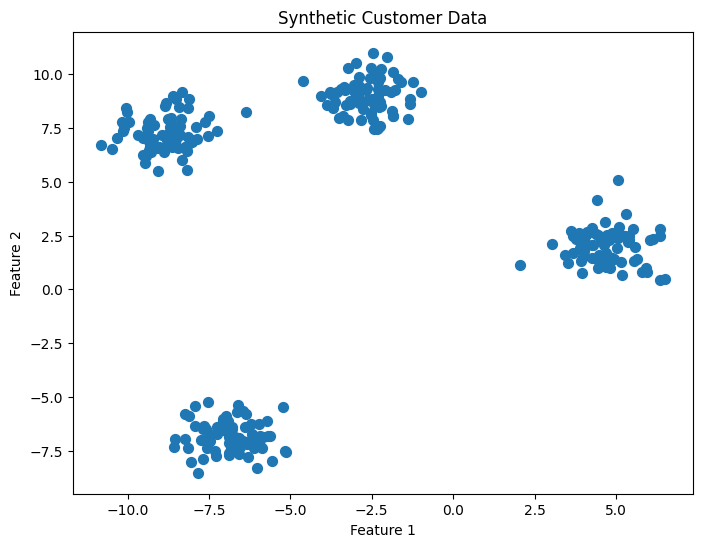

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Customer Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

This code is doing a complete unsupervised learning workflow: first clustering synthetic customer data with K-Means, then reducing and visualizing the Iris dataset with PCA.



### Task 1: Find the Optimal Number of Clusters (The Elbow Method)**Concept:** How do we know what `k` should be? The **Elbow Method** helps us decide. We run K-Means for a range of `k` values and for each `k`, we calculate the **inertia** (the sum of squared distances of samples to their closest cluster center). We then plot the inertia for each `k`. The "elbow" of the curve—the point where the inertia starts to decrease much more slowly—is a good estimate for the optimal `k`.**Your Task:** Calculate and plot the inertia for `k` values from 1 to 10.

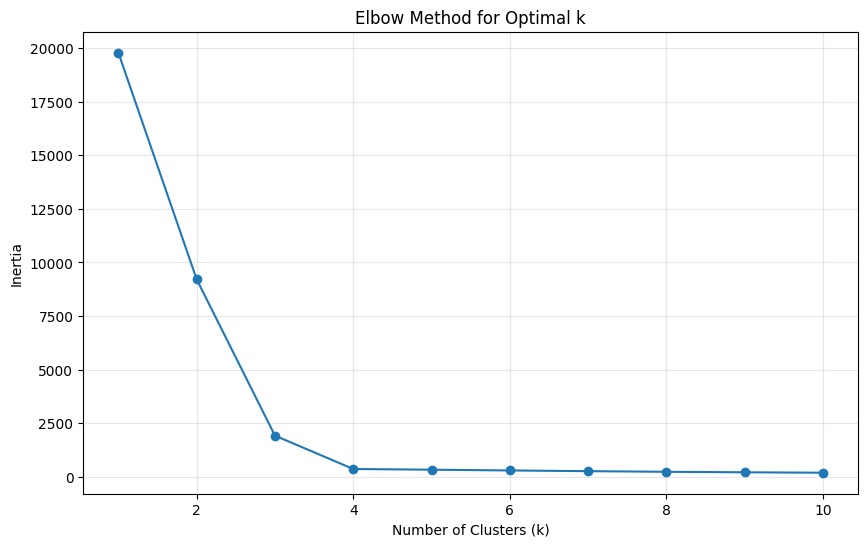

In [9]:
from sklearn.cluster import KMeans

# Create an empty list to store the inertia values
inertia = []

# Loop through k values from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.show()

**Elbow Method**

In this task, I ran K-Means for values of k from 1 to 10 and recorded the inertia, which is the sum of squared distances from each point to its nearest cluster center. Plotting inertia versus k shows how quickly the clustering quality improves as we add more clusters.

The curve bends (forms an “elbow”) around k = 4, where the decrease in inertia starts to slow down, so k = 4 is a good choice because it balances compact clusters with a simple, interpretable number of groups instead of overfitting with too many clusters.




### Task 2: Perform K-Means Clustering and VisualizeFrom the elbow plot, it looks like `k=4` is the optimal number of clusters.**Your Task:** Run K-Means with `n_clusters=4` and create a scatter plot showing the data points colored by their assigned cluster.

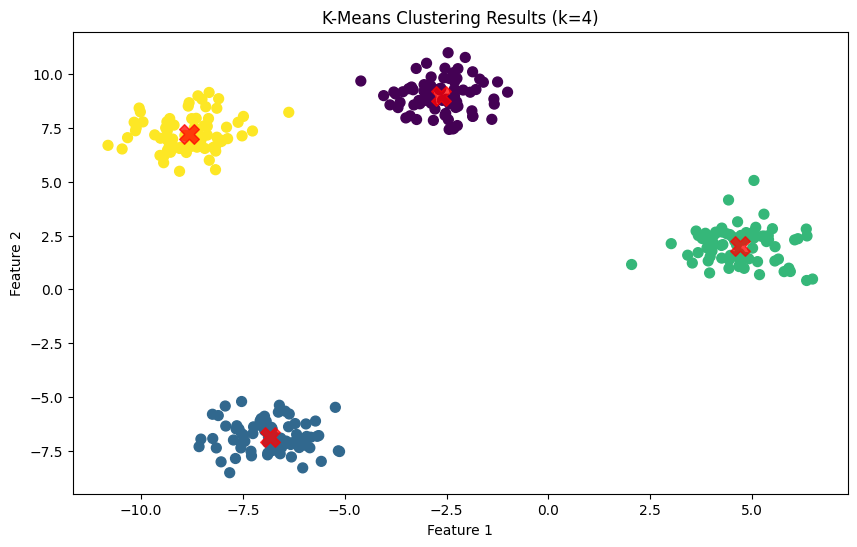

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create and fit a KMeans model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

# Get cluster assignments and cluster centers
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Plot the clustered data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')

plt.title('K-Means Clustering Results (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**K-Means Clustering**

In this task, I fit a K-Means model with k = 4 clusters to the synthetic customer spending data and assigned each point to one of the four clusters. The scatter plot colors each data point by its cluster label and marks the cluster centers (centroids) to show where the algorithm places the “typical” customer for each group.

Visually, the points within each cluster are close together and separated from other clusters, which suggests that K-Means successfully grouped customers with similar feature values into four meaningful segments that could represent different spending patterns.



## Part 3: Principal Component Analysis (PCA)**Concept:** PCA is a dimensionality reduction technique. It transforms the data into a new coordinate system of **principal components**. These components are orthogonal (uncorrelated) and are ordered by the amount of variance in the data they explain. By keeping only the first few principal components, we can reduce the number of dimensions in our data while losing as little information as possible.**Use Cases:***   **Visualization:** Reducing high-dimensional data to 2 or 3 dimensions so we can plot it.*   **Performance:** Speeding up model training by using fewer features.**Problem:** We will use the Iris dataset, which has 4 features, and reduce it to 2 features so we can visualize it.

### Task 3: Apply PCA to the Iris Dataset**Your Task:** Use `PCA` from `sklearn.decomposition` to reduce the 4-dimensional Iris dataset to 2 principal components and visualize the result.

Explained variance by component: [0.92461872 0.05306648]
Total variance explained by 2 components: 97.77%


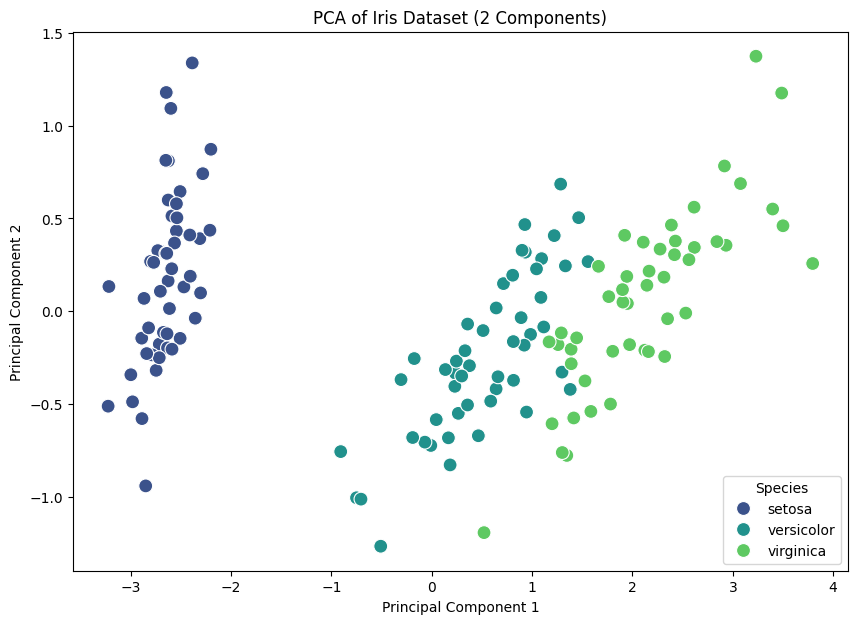

In [11]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Create a PCA model to reduce the data to 2 principal components
pca = PCA(n_components=2)

# Fit PCA and transform the data
X_pca = pca.fit_transform(X_iris)

# Print the explained variance ratio
print(f"Explained variance by component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# Create a DataFrame for plotting
pca_df = pd.DataFrame(
    data=X_pca,
    columns=["Principal Component 1", "Principal Component 2"]
)

# Use actual species names instead of numeric labels
pca_df["Species"] = [iris.target_names[i] for i in y_iris]

# Plot the PCA results
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Species",
    data=pca_df,
    palette="viridis",
    s=100
)

plt.title("PCA of Iris Dataset (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Species")
plt.show()

**PCA on Iris**

Here I used PCA to reduce the 4-dimensional Iris dataset down to 2 principal components and plotted the data in this new 2D space. The scatter plot shows each flower as a point, colored by species, which lets me see how well the species separate after dimensionality reduction.

The first two principal components explained about 97.77% of the total variance, meaning that almost all of the information contained in the original 4 features is preserved in these 2 dimensions, so the 2D visualization is a very faithful summary of the original data.



## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **What is the fundamental difference between supervised and unsupervised learning?**2.  **In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**3.  **In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?****[ENTER YOUR ANSWERS HERE]**

## Knowledge Check

1. **What is the fundamental difference between supervised and unsupervised learning?**  
Supervised learning uses labeled data, where we have both features X and a target y, and the goal is to learn a mapping from inputs to outputs. Unsupervised learning only has the features X and tries to discover patterns or structure in the data without any target labels.

2. **Why don't we choose the largest possible k in the elbow plot?**  
Increasing k will always reduce inertia, but very large k values can overfit by creating many small, less meaningful clusters that are hard to interpret. The elbow point is preferred because it gives a good trade-off between low inertia and a simple, interpretable number of clusters.

3. **What does it mean that the first two principal components explain over 95% of the variance?**  
It means the original 4-dimensional Iris dataset can be represented very well in 2 dimensions with very little information loss. This shows that most of the important structure in the data is captured by the first two principal components.